In [ ]:
!pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.8 MB/s eta 0:00:00


In [ ]:
from google_play_scraper import reviews, Sort
import pandas as pd

result, _ = reviews(
    'com.fsn.nykaa',
    lang='en',
    country='in',
    sort=Sort.NEWEST,
    count=5000
)

df = pd.DataFrame(result)
print(f"Total reviews scraped: {len(df)}")
print(df.head())

Total reviews scraped: 5000
                               reviewId       userName  \
0  44df59d1-211a-4875-8030-bff4723e1ac8  A Google user   
1  ad5767d6-9dd6-49ce-8693-aaf424d04f0a  A Google user   
2  cf9e5401-96c0-4bde-9268-f3bf8fe9e73f  A Google user   
3  e6a8e8a7-8890-43cf-be15-e049f253ee0f  A Google user   
4  5e2e82bc-f993-41b8-9e50-b1f205493c4f  A Google user   

                                           userImage  \
0  https://play-lh.googleusercontent.com/EGemoI2N...   
1  https://play-lh.googleusercontent.com/EGemoI2N...   
2  https://play-lh.googleusercontent.com/EGemoI2N...   
3  https://play-lh.googleusercontent.com/EGemoI2N...   
4  https://play-lh.googleusercontent.com/EGemoI2N...   

                                      content  score  thumbsUpCount  \
0                                           👌      5              0   
1  I love this app for all my beauty products      5              0   
2                                good service      4              0   
3 

In [ ]:
df.to_csv('nykaa_reviews.csv', index=False)

print("Rating distribution:")
print(df['score'].value_counts().sort_index())

print(f"\nDate range: {df['at'].min()} to {df['at'].max()}")
print(f"\nColumns: {df.columns.tolist()}")

Rating distribution:
score
1     908
2     147
3     278
4     716
5    2951
Name: count, dtype: int64

Date range: 2026-02-08 04:55:11 to 2026-03-22 10:46:42

Columns: ['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion']


In [ ]:
# Remove reviews with no text content
df = df[df['content'].notna()]
df = df[df['content'].str.strip() != '']

# Classify into positive, neutral, negative
df['sentiment'] = df['score'].apply(
    lambda x: 'positive' if x >= 4 else ('neutral' if x == 3 else 'negative')
)

# Convert date column properly
df['at'] = pd.to_datetime(df['at'])
df['date'] = df['at'].dt.date
df['week'] = df['at'].dt.to_period('W')

print(f"Reviews after cleaning: {len(df)}")
print(df['sentiment'].value_counts())

Reviews after cleaning: 5000
sentiment
positive    3667
negative    1055
neutral      278
Name: count, dtype: int64


In [ ]:
negative_df = df[df['sentiment'] == 'negative'].copy()
print(f"Total negative reviews: {len(negative_df)}")
print("\nSample negative reviews:")
print(negative_df['content'].head(10).tolist())

Total negative reviews: 1055

Sample negative reviews:
["Very bad Experience. First they sent me the product that is already look like used and when I wanted to return it then they said I have used it that they can't accept return. Even I haven't touched the item. How can they say by photo that I have used it if they don't see by physically. Sorry my experience was very bad.", 'good', "literally Day by Day this app is becoming worst the mostly bad service on delivering the order it's just keep on delaying the order what is the use of making orders if it doesn't deliver on time literally made me sad quality is good but delivery service is worst", 'too expensive', 'waste product faltu product Not working', 'worst app!', 'very bad service.After placing a pre paid order 1 st they show a date to deliver the order,then extend it 2 times .After then they will show undefined delayed.No information of the order will be seen in the app.No customer care help line will help.wrost app.Dont prepaid 

In [ ]:
# Reviews other users found helpful are more credible signals
helpful_negative = negative_df[negative_df['thumbsUpCount'] > 5].sort_values(
    'thumbsUpCount', ascending=False
)
print(f"Highly helpful negative reviews: {len(helpful_negative)}")
print("\nTop 10 most helpful negative reviews:\n")
for i, row in helpful_negative.head(10).iterrows():
    print(f"👍 {row['thumbsUpCount']} | ⭐{row['score']} | {row['content'][:200]}")
    print("---")

Highly helpful negative reviews: 32

Top 10 most helpful negative reviews:

👍 122 | ⭐1 | Kind of a fraud app. I have faced numerous delayed deliveries, and every time I contacted customer support, I received the same generic response. They are not aware of the reason for the delay and can
---
👍 104 | ⭐2 | Nykaa's delivery service is getting worse with each successive order. Now when I order something , items come to my nearest delivery place and then it takes forever for their delivery partner to deliv
---
👍 98 | ⭐1 | I had always heard good things about Nykaa, which is why I decided to install the app. Unfortunately, my experience turned out to be extremely disappointing. I ordered a mascara and a highlighter, but
---
👍 91 | ⭐1 | Nykaa's delivery service is totally worse . Now when I order something, items come to my nearest delivery place and then it takes forever for their delivery partner to deliver the product. Even after 
---
👍 66 | ⭐1 | Why are you guys scamming customers ? I ha

In [ ]:
import re

def categorise_complaint(text):
    text = text.lower()

    if any(word in text for word in [
        'fake', 'duplicate', 'original', 'authentic',
        'counterfeit', 'expired', 'tampered', 'seal'
    ]):
        return 'Fake/Authenticity'

    elif any(word in text for word in [
        'delivery', 'delayed', 'late', 'not delivered',
        'xpressbees', 'courier', 'shipping', 'dispatch',
        'hub', 'out for delivery', 'days'
    ]):
        return 'Delivery Issues'

    elif any(word in text for word in [
        'return', 'refund', 'exchange', 'pickup',
        'money back', 'cancel', 'cancelled'
    ]):
        return 'Returns & Refunds'

    elif any(word in text for word in [
        'customer support', 'customer care', 'helpline',
        'agent', 'response', 'no reply', 'useless support',
        'chat support', 'call'
    ]):
        return 'Customer Support'

    elif any(word in text for word in [
        'wrong product', 'wrong item', 'different product',
        'missing item', 'incomplete order', 'wrong shade',
        'wrong colour', 'not what i ordered'
    ]):
        return 'Wrong/Missing Product'

    elif any(word in text for word in [
        'app crash', 'not loading', 'error', 'bug',
        'glitch', 'slow', 'app issue', 'not working',
        'payment failed', 'checkout'
    ]):
        return 'App/Technical Issues'

    elif any(word in text for word in [
        'points', 'reward', 'cashback', 'coins',
        'discount', 'coupon', 'offer'
    ]):
        return 'Rewards & Offers'

    else:
        return 'Other'

# Apply to negative reviews
negative_df['category'] = negative_df['content'].apply(categorise_complaint)

# See the distribution
category_counts = negative_df['category'].value_counts()
print("Complaint categories:\n")
print(category_counts)
print(f"\nTotal categorised: {len(negative_df)}")

Complaint categories:

category
Delivery Issues          421
Other                    370
Returns & Refunds        125
Fake/Authenticity         46
Rewards & Offers          46
Customer Support          29
App/Technical Issues      16
Wrong/Missing Product      2
Name: count, dtype: int64

Total categorised: 1055


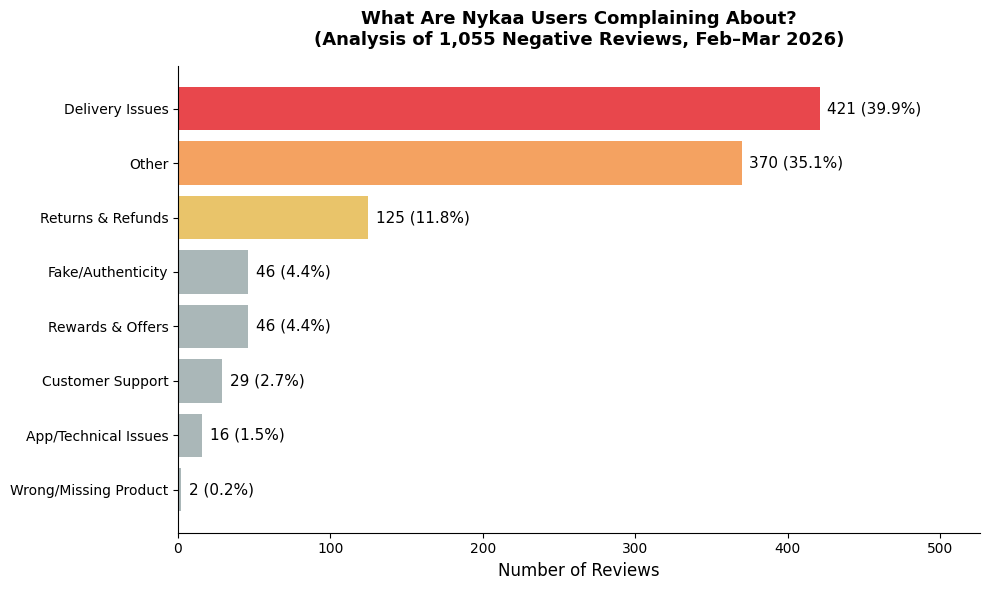

Chart saved.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#E8474C' if i == 0 else '#F4A261' if i == 1
          else '#E9C46A' if i == 2 else '#AAB7B8'
          for i in range(len(category_counts))]

bars = ax.barh(category_counts.index[::-1],
               category_counts.values[::-1],
               color=colors[::-1], edgecolor='none')

# Add value labels
for bar, val in zip(bars, category_counts.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val} ({val/len(negative_df)*100:.1f}%)',
            va='center', fontsize=11)

ax.set_xlabel('Number of Reviews', fontsize=12)
ax.set_title("What Are Nykaa Users Complaining About?\n(Analysis of 1,055 Negative Reviews, Feb–Mar 2026)",
             fontsize=13, fontweight='bold', pad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0, max(category_counts.values) * 1.25)

plt.tight_layout()
plt.savefig('nykaa_complaint_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [ ]:
other_df = negative_df[negative_df['category'] == 'Other'].copy()

print(f"Total 'Other' reviews: {len(other_df)}")
print("\n--- Sample 20 'Other' reviews ---\n")
for i, row in other_df.sample(20, random_state=42).iterrows():
    print(f"⭐{row['score']} | {row['content'][:250]}")
    print("---")

Total 'Other' reviews: 370

--- Sample 20 'Other' reviews ---

⭐1 | bekar hai wrog prodect aate hai isse na le
---
⭐1 | not open security alert problm 😔
---
⭐2 | 👍
---
⭐1 | Oder karne ke bad shipped to ho jata hai par delever hi nahi ho raha hai mein last one month se persan hu boycott nykaa worst worst experience 😡😡😡
---
⭐1 | bhut accha prodact h
---
⭐2 | good
---
⭐1 | very fraud app...don't purchase plz
---
⭐1 | very bad service
---
⭐1 | worse service
---
⭐1 | good
---
⭐2 | app does not properly working
---
⭐1 | very expensive 😔
---
⭐1 | cost higher
---
⭐2 | payment page interface very bad
---
⭐1 | worst app
---
⭐2 | nykaa is doing only business playing with people emotion
---
⭐1 | good
---
⭐1 | my experience is not good .third class material u sale .no gripping in bob pins.i am very unsatisfied with your products.
---
⭐2 | worst app my order was supposed to be deliver on 9th feb.bt on status they r showing 10th .On 10th it is showing 11th and it continues...what the hell is this...w

In [ ]:
delivery_df = negative_df[negative_df['category'] == 'Delivery Issues'].copy()

weekly_delivery = delivery_df.groupby('week').size().reset_index(name='count')
weekly_all_negative = negative_df.groupby('week').size().reset_index(name='total')

weekly = weekly_delivery.merge(weekly_all_negative, on='week')
weekly['delivery_pct'] = (weekly['count'] / weekly['total'] * 100).round(1)

print(weekly[['week', 'count', 'total', 'delivery_pct']].to_string())

                    week  count  total  delivery_pct
0  2026-02-02/2026-02-08      4     34          11.8
1  2026-02-09/2026-02-15     88    209          42.1
2  2026-02-16/2026-02-22     86    193          44.6
3  2026-02-23/2026-03-01     63    164          38.4
4  2026-03-02/2026-03-08     60    161          37.3
5  2026-03-09/2026-03-15     64    160          40.0
6  2026-03-16/2026-03-22     56    134          41.8


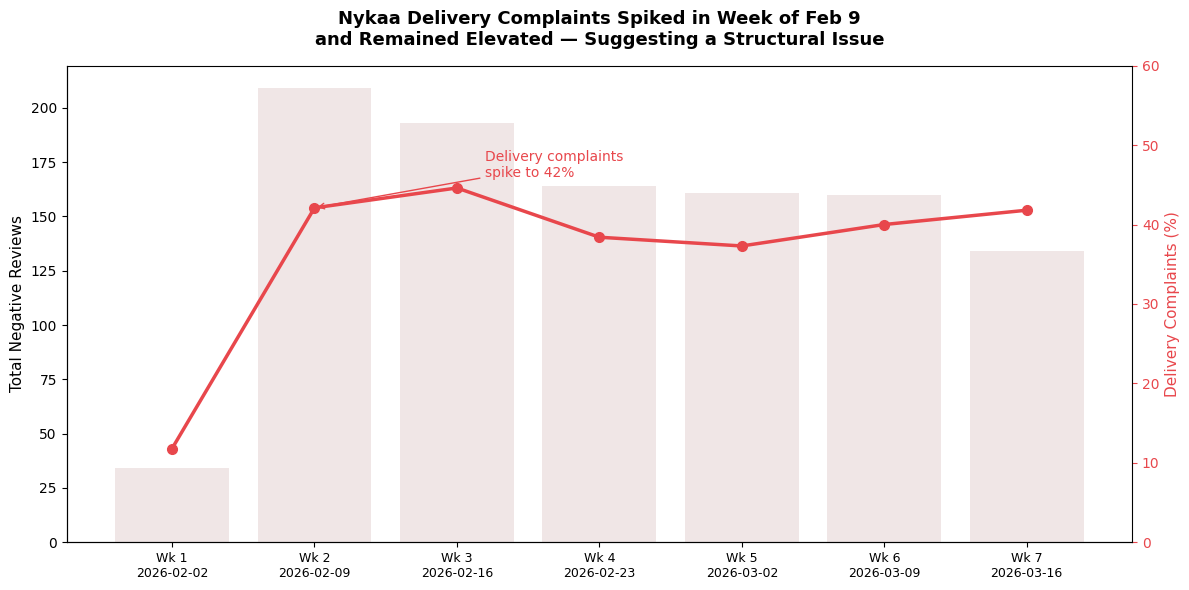

Chart saved.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax1 = plt.subplots(figsize=(12, 6))

weeks = [str(w) for w in weekly['week']]
x = range(len(weeks))

# Bar chart — total negative reviews per week
ax1.bar(x, weekly['total'], color='#F0E6E6',
        label='Total negative reviews', zorder=1)

# Line chart — delivery complaint %
ax2 = ax1.twinx()
ax2.plot(x, weekly['delivery_pct'], color='#E8474C',
         linewidth=2.5, marker='o', markersize=7,
         label='Delivery complaints %', zorder=2)

# Mark the spike
ax2.annotate('Delivery complaints\nspike to 42%',
             xy=(1, 42.1), xytext=(2.2, 46),
             arrowprops=dict(arrowstyle='->', color='#E8474C'),
             fontsize=10, color='#E8474C')

ax1.set_xticks(x)
ax1.set_xticklabels([f"Wk {i+1}\n{w[:10]}" for i, w in enumerate(weeks)],
                     fontsize=9)
ax1.set_ylabel('Total Negative Reviews', fontsize=11)
ax2.set_ylabel('Delivery Complaints (%)', fontsize=11, color='#E8474C')
ax2.set_ylim(0, 60)
ax2.tick_params(axis='y', colors='#E8474C')

ax1.set_title("Nykaa Delivery Complaints Spiked in Week of Feb 9\nand Remained Elevated — Suggesting a Structural Issue",
              fontsize=13, fontweight='bold', pad=15)

ax1.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('nykaa_delivery_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [ ]:
top_delivery = delivery_df.sort_values(
    'thumbsUpCount', ascending=False
).head(10)

print("Top 10 most upvoted DELIVERY complaints:\n")
for i, row in top_delivery.iterrows():
    print(f"👍{row['thumbsUpCount']} | {row['at'].date()} | {row['content'][:300]}")
    print("---")

Top 10 most upvoted DELIVERY complaints:

👍122 | 2026-02-08 | Kind of a fraud app. I have faced numerous delayed deliveries, and every time I contacted customer support, I received the same generic response. They are not aware of the reason for the delay and cannot provide a definite delivery date. Please be extra cautious while placing prepaid orders. It is a
---
👍104 | 2026-02-13 | Nykaa's delivery service is getting worse with each successive order. Now when I order something , items come to my nearest delivery place and then it takes forever for their delivery partner to deliver the product . Even after complaining several times no actions have been taken . I order, my deliv
---
👍98 | 2026-02-11 | I had always heard good things about Nykaa, which is why I decided to install the app. Unfortunately, my experience turned out to be extremely disappointing. I ordered a mascara and a highlighter, but during delivery, the delivery person handed me two boxes and asked for extra money, sayi

In [ ]:
# Extract delivery partner mentions from delivery complaints
partners = {
    'Xpressbees': 0,
    'Shadowfax': 0,
    'Delhivery': 0,
    'Ekart': 0,
    'Bluedart': 0, # Changed from 'BlueDart' to 'Bluedart' to match partner.capitalize()
    'Other/Unspecified': 0
}

for review in delivery_df['content'].str.lower():
    matched = False
    for partner in ['xpressbees', 'shadowfax', 'delhivery',
                    'ekart', 'bluedart']:
        if partner in review:
            partners[partner.capitalize()] += 1
            matched = True
    if not matched:
        partners['Other/Unspecified'] += 1

partner_df = pd.Series(partners).sort_values(ascending=False)
print("Delivery partner mentions in complaints:")
print(partner_df)

Delivery partner mentions in complaints:
Other/Unspecified    404
Shadowfax              9
Bluedart               7
Xpressbees             2
Ekart                  0
Delhivery              0
dtype: int64


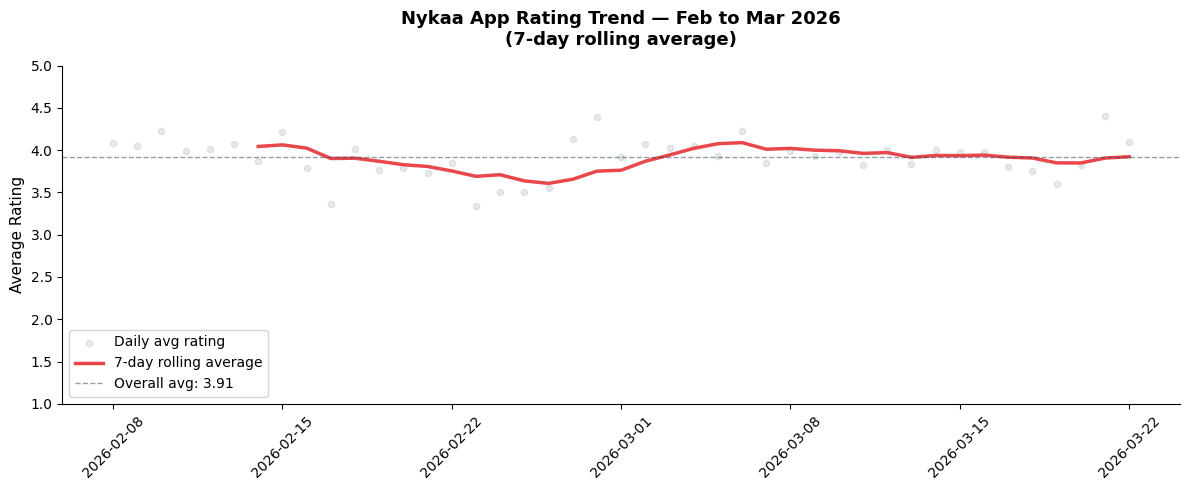

In [ ]:
daily_avg = df.groupby('date')['score'].mean().reset_index()
daily_avg['rolling_avg'] = daily_avg['score'].rolling(window=7).mean()

fig, ax = plt.subplots(figsize=(12, 5))

ax.scatter(daily_avg['date'], daily_avg['score'],
           alpha=0.3, color='#AAB7B8', s=20, label='Daily avg rating')
ax.plot(daily_avg['date'], daily_avg['rolling_avg'],
        color='#E8474C', linewidth=2.5, label='7-day rolling average')

ax.axhline(y=daily_avg['score'].mean(), color='#2C3E50',
           linestyle='--', linewidth=1, alpha=0.5,
           label=f"Overall avg: {daily_avg['score'].mean():.2f}")

ax.set_ylim(1, 5)
ax.set_ylabel('Average Rating', fontsize=11)
ax.set_title("Nykaa App Rating Trend — Feb to Mar 2026\n(7-day rolling average)",
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('nykaa_rating_trend.png', dpi=150, bbox_inches='tight')
plt.show()

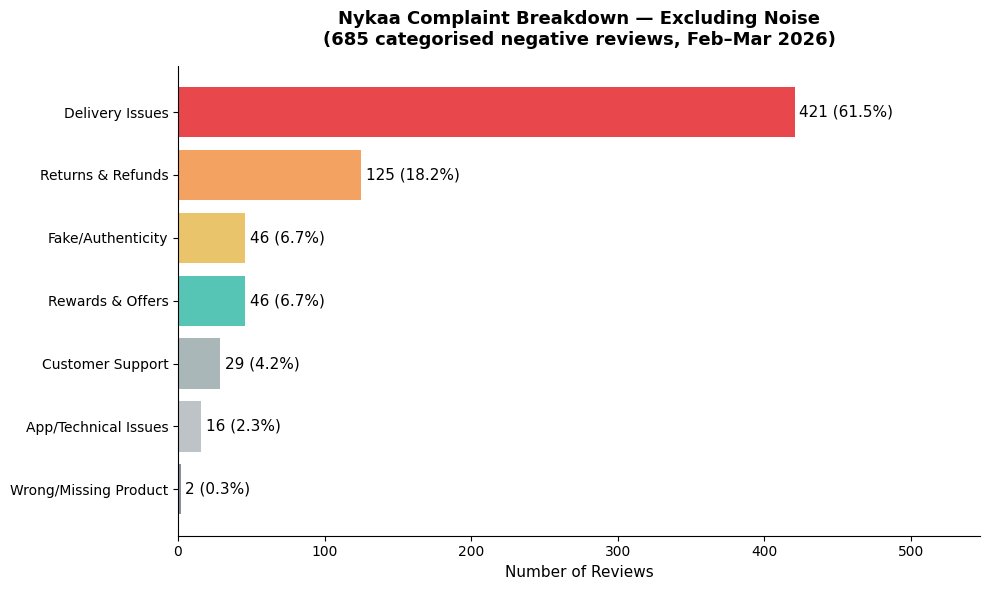

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Exclude 'Other' since we know it's mostly noise + Hinglish
clean_categories = category_counts[category_counts.index != 'Other']
total_clean = clean_categories.sum()

colors_list = ['#E8474C', '#F4A261', '#E9C46A',
               '#57C5B6', '#AAB7B8', '#BDC3C7', '#85929E']

bars = ax.barh(clean_categories.index[::-1],
               clean_categories.values[::-1],
               color=colors_list[:len(clean_categories)][::-1],
               edgecolor='none')

for bar, val in zip(bars, clean_categories.values[::-1]):
    pct = val / total_clean * 100
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            f'{val} ({pct:.1f}%)', va='center', fontsize=11)

ax.set_xlabel('Number of Reviews', fontsize=11)
ax.set_title("Nykaa Complaint Breakdown — Excluding Noise\n(685 categorised negative reviews, Feb–Mar 2026)",
             fontsize=13, fontweight='bold', pad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0, max(clean_categories.values) * 1.3)
plt.tight_layout()
plt.savefig('nykaa_complaints_clean.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Findings & Product Recommendations

### Finding 1 — Delivery is the dominant retention risk
61.5% of all categorised negative reviews (421/685) are about delivery
failures. Complaints spiked from 11.8% to 42.1% of weekly negative
sentiment in the week of Feb 9, 2026 and remained elevated for 6
consecutive weeks — suggesting a structural breakdown in last-mile
delivery, not a one-time incident.

Recommendation: Nykaa should conduct an immediate last-mile delivery
partner audit — particularly Shadowfax and BlueDart who are explicitly
named in complaints. Introduce a delivery partner performance scorecard
tracking on-time delivery rate, failed delivery attempts, and complaint
volume per partner. Partners below threshold should be deprioritised in
routing logic.

---

### Finding 2 — The app is making promises the logistics network can't keep
Multiple high-upvote reviews (👍39, 👍22) cite same-day or express
delivery being shown at checkout but not honoured. The ETA promise
displayed in the app is disconnected from actual delivery partner
capacity — creating expectation mismatch that drives 1-star reviews even
when the product itself is fine.

Recommendation: Build a real-time ETA model that factors in delivery
partner capacity, pin code serviceability, and historical delivery
performance before surfacing same-day or express delivery promises.
Showing a slightly longer but accurate ETA is better for retention than
a fast promise that fails — Amazon's model of conservative-then-early
delivery is a proven benchmark.

---

### Finding 3 — Users can't see who is delivering their order
404 out of 421 delivery complaints (95.9%) do not name a specific
delivery partner — indicating users have no visibility into which
logistics company is handling their shipment. When things go wrong,
they have no direct recourse and escalate to Nykaa's customer support
instead, increasing support load unnecessarily.

Recommendation: Display the delivery partner name, contact number,
and live tracking link prominently on the order tracking page — similar
to how Zomato shows the delivery agent's name and phone number. This
reduces customer support contacts for delivery issues and gives users
agency to resolve last-mile problems directly, improving satisfaction
without requiring operational changes.
```